# LoRA Bench — Exploration & Checkpoint Testing

Run from `lora-bench/notebooks/`. Paths relative to parent `lora-bench/`.

**Pipeline**
1. Env + paths
2. Discover all training runs (incl. failed)
3. Plot **TF events** (train loss / eval loss / grad_norm / entropy / LR)
4. Load + test SFT checkpoint
5. Load + test DPO checkpoint
6. Side-by-side eval (acc / tok-s / mem)
7. Free-form interactive prompt

Each cell is **independent** — re-run any single cell after kernel restart.

## 1. Env & paths

In [4]:
import sys, os, json, gc
from pathlib import Path
sys.path.insert(0, '..')

from src.utils import get_device, load_run_cfg, log_env, set_seed, count_trainable

DEVICE = get_device()
print(log_env(DEVICE))
set_seed(42)

RUNS_DIR    = Path('../runs')
RESULTS_DIR = Path('../results')
SFT_NAME    = 'qwen3_06b_sft_gsm8k'
DPO_NAME    = 'qwen3_06b_op_dpo_gtw'
SFT_CKPT    = RUNS_DIR / SFT_NAME / 'final'   # bad run, step 500 (before divergence at ~720)
DPO_CKPT    = RUNS_DIR / DPO_NAME / 'checkpoint-100'

print(f'\nSFT ckpt: {SFT_CKPT}  exists={SFT_CKPT.exists()}')
print(f'DPO ckpt: {DPO_CKPT}  exists={DPO_CKPT.exists()}')
print(f'runs dir contents:')
for p in sorted(RUNS_DIR.iterdir()) if RUNS_DIR.exists() else []:
    print('  -', p.name)

{'device': 'mps', 'torch': '2.11.0'}

SFT ckpt: ../runs/qwen3_06b_sft_gsm8k/final  exists=True
DPO ckpt: ../runs/qwen3_06b_op_dpo_gtw/checkpoint-100  exists=True
runs dir contents:
  - qwen3_06b_dpo_math
  - qwen3_06b_op_dpo_gtw
  - qwen3_06b_sft_gsm8k
  - qwen3_06b_sft_gsm8k_bad_lr2e4_epoch3


## 2. Discover all TF event files

In [5]:
from glob import glob

def find_tb_events(run_root='../runs'):
    """Returns dict {run_name: latest_event_file_path}."""
    found = {}
    for run_dir in sorted(Path(run_root).iterdir()) if Path(run_root).exists() else []:
        if not run_dir.is_dir(): continue
        events = sorted(glob(str(run_dir / '**' / 'events.out.tfevents.*'), recursive=True))
        if events:
            found[run_dir.name] = events[-1]   # most recent
    return found

tb = find_tb_events()
for name, p in tb.items():
    print(f'{name}: {p}')
if not tb:
    print('No event files yet — training not started or no scalars logged.')

qwen3_06b_dpo_math: ../runs/qwen3_06b_dpo_math/runs/May11_02-05-20_AP250806.local/events.out.tfevents.1778457920.AP250806.local.88549.0
qwen3_06b_op_dpo_gtw: ../runs/qwen3_06b_op_dpo_gtw/tb/events.out.tfevents.1778480543.AP250806.local.6069.0
qwen3_06b_sft_gsm8k: ../runs/qwen3_06b_sft_gsm8k/runs/May10_21-58-57_AP250806.local/events.out.tfevents.1778443137.AP250806.local.73320.0
qwen3_06b_sft_gsm8k_bad_lr2e4_epoch3: ../runs/qwen3_06b_sft_gsm8k_bad_lr2e4_epoch3/runs/May10_18-17-38_AP250806.local/events.out.tfevents.1778429858.AP250806.local.88778.0


## 3. Plot TF event scalars

qwen3_06b_dpo_math — tags: ['train/loss', 'train/grad_norm', 'train/learning_rate', 'train/entropy', 'train/num_tokens', 'train/logits/chosen', 'train/logits/rejected', 'train/mean_token_accuracy', 'train/rewards/chosen', 'train/rewards/rejected', 'train/rewards/accuracies', 'train/rewards/margins', 'train/logps/chosen', 'train/logps/rejected', 'train/epoch', 'eval/loss', 'eval/runtime', 'eval/samples_per_second', 'eval/steps_per_second', 'eval/entropy', 'eval/num_tokens', 'eval/logits/chosen', 'eval/logits/rejected', 'eval/mean_token_accuracy', 'eval/rewards/chosen', 'eval/rewards/rejected', 'eval/rewards/accuracies', 'eval/rewards/margins', 'eval/logps/chosen', 'eval/logps/rejected', 'train/train_runtime', 'train/train_samples_per_second', 'train/train_steps_per_second', 'train/total_flos', 'train/train_loss']


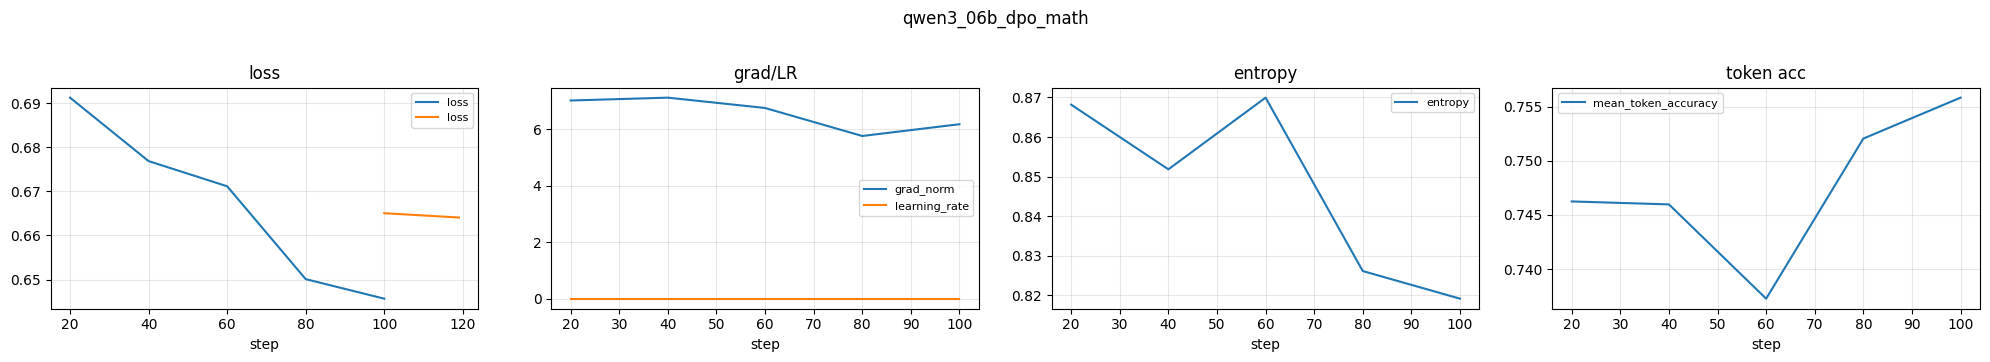

qwen3_06b_op_dpo_gtw — tags: ['beta', 'n_pairs', 'mean_reward', 'loss', 'loss_dpo_seq', 'loss_dpo_tok', 'loss_sft', 'loss_kl', 'wall_s', 'lr']


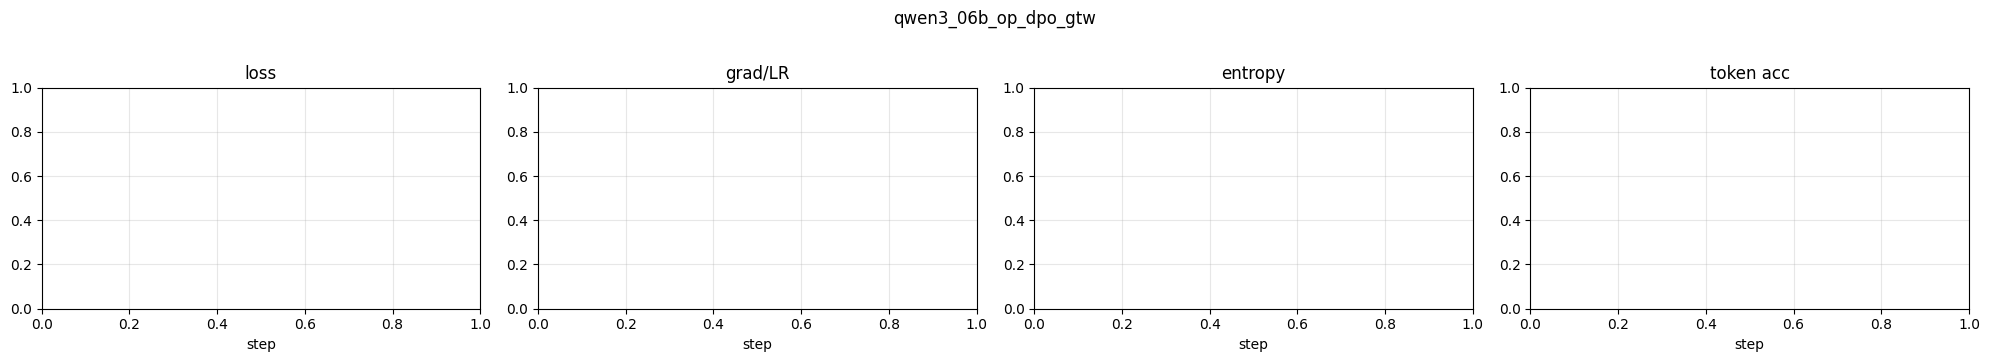

qwen3_06b_sft_gsm8k — tags: ['train/loss', 'train/grad_norm', 'train/learning_rate', 'train/entropy', 'train/num_tokens', 'train/mean_token_accuracy', 'train/epoch', 'eval/loss', 'eval/runtime', 'eval/samples_per_second', 'eval/steps_per_second', 'eval/entropy', 'eval/num_tokens', 'eval/mean_token_accuracy', 'train/train_runtime', 'train/train_samples_per_second', 'train/train_steps_per_second', 'train/total_flos', 'train/train_loss']


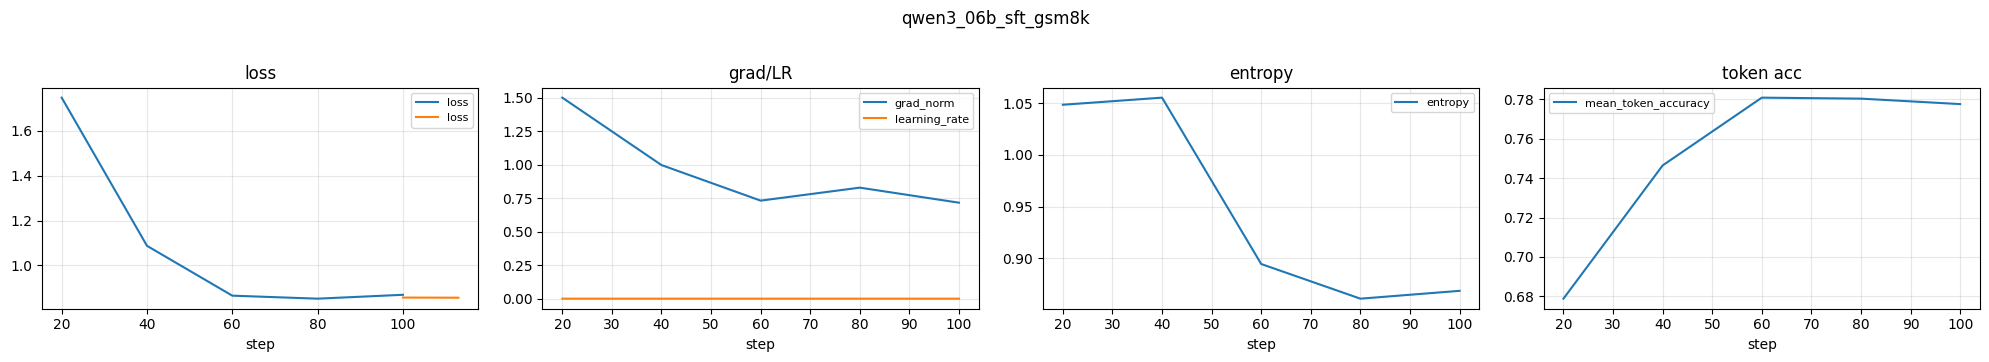

qwen3_06b_sft_gsm8k_bad_lr2e4_epoch3 — tags: ['train/loss', 'train/grad_norm', 'train/learning_rate', 'train/entropy', 'train/num_tokens', 'train/mean_token_accuracy', 'train/epoch']


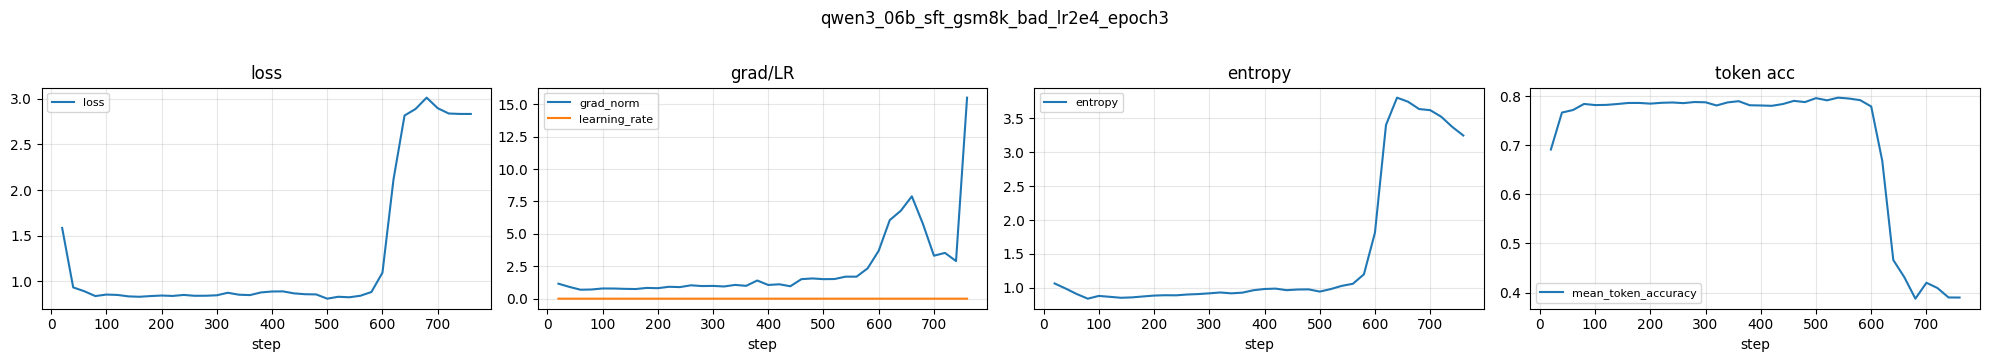

In [6]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def load_scalars(event_path):
    ea = EventAccumulator(event_path, size_guidance={'scalars': 0})
    ea.Reload()
    tags = ea.Tags().get('scalars', [])
    return {t: ea.Scalars(t) for t in tags}

def plot_run(run_name, event_path, panels=None):
    """panels: list of (title, [tags]). Default: loss/grad/lr/entropy."""
    scalars = load_scalars(event_path)
    tags = list(scalars.keys())
    print(f'{run_name} — tags: {tags}')
    if panels is None:
        panels = [
            ('loss',     ['train/loss', 'eval/loss']),
            ('grad/LR',  ['train/grad_norm', 'train/learning_rate']),
            ('entropy',  ['train/entropy']),
            ('token acc',['train/mean_token_accuracy']),
        ]
    fig, axes = plt.subplots(1, len(panels), figsize=(5*len(panels), 3.5))
    if len(panels) == 1: axes = [axes]
    for ax, (title, want) in zip(axes, panels):
        plotted = False
        for t in want:
            if t not in scalars: continue
            ev = scalars[t]
            if not ev: continue
            ax.plot([e.step for e in ev], [e.value for e in ev], label=t.split('/')[-1])
            plotted = True
        ax.set_title(title); ax.set_xlabel('step'); ax.grid(True, alpha=0.3)
        if plotted: ax.legend(fontsize=8)
    fig.suptitle(run_name, y=1.02)
    plt.tight_layout()
    plt.show()

for name, path in tb.items():
    plot_run(name, path)

### Compare runs head-to-head (e.g. bad vs good SFT)

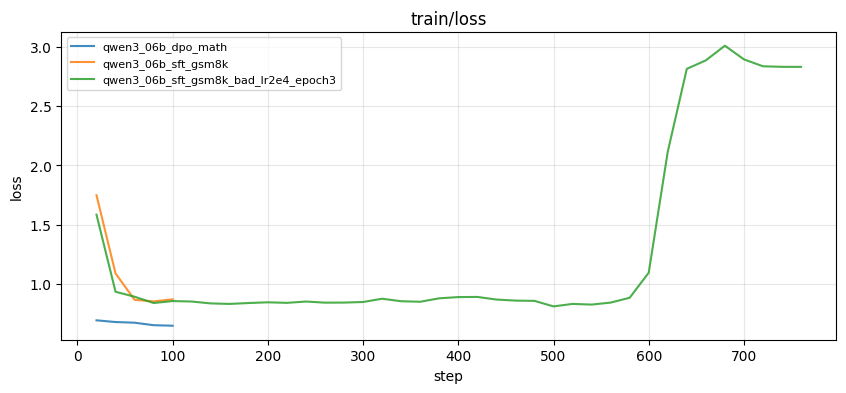

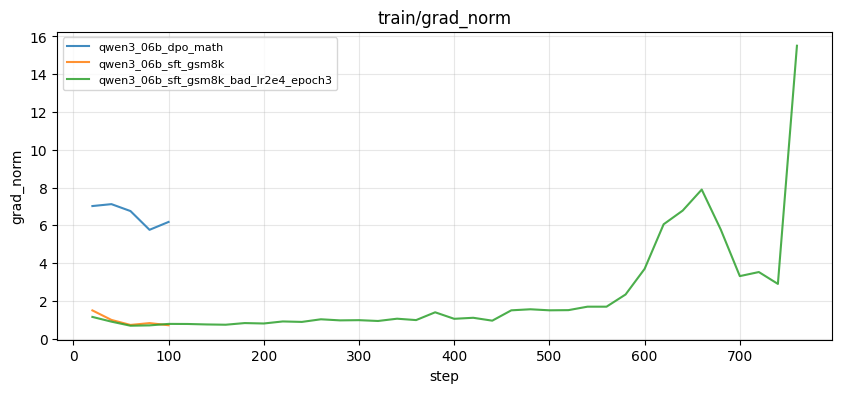

In [7]:
def compare_runs(tb_map, tag='train/loss'):
    fig, ax = plt.subplots(figsize=(10, 4))
    for name, path in tb_map.items():
        scalars = load_scalars(path)
        if tag not in scalars: continue
        ev = scalars[tag]
        ax.plot([e.step for e in ev], [e.value for e in ev], label=name, alpha=0.85)
    ax.set_title(tag); ax.set_xlabel('step'); ax.set_ylabel(tag.split('/')[-1])
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    plt.show()

compare_runs(tb, 'train/loss')
compare_runs(tb, 'train/grad_norm')

## 4. Test SFT checkpoint

In [8]:
import torch
from src.model import load_tokenizer, load_base_model, load_model_with_lora
from src.data import format_qwen_prompt_only, parse_predicted_answer, load_gsm8k_for_eval
from src.eval import evaluate

cfg = load_run_cfg('../configs/base.yaml', '../configs/sft_gsm8k.yaml')
tok = load_tokenizer(cfg)

def load_model(adapter_path=None):
    if adapter_path:
        m = load_model_with_lora(cfg, DEVICE, adapter_path=str(adapter_path))
    else:
        m = load_base_model(cfg, DEVICE)
    m.eval()
    return m

@torch.no_grad()
def gen(model, question, max_new_tokens=384, do_sample=False, temperature=0.7):
    prompt = format_qwen_prompt_only(question, tok)
    inputs = tok(prompt, return_tensors='pt').to(DEVICE)
    out = model.generate(
        **inputs, max_new_tokens=max_new_tokens, do_sample=do_sample,
        temperature=temperature if do_sample else 1.0,
        pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id,
    )
    return tok.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

QUESTIONS = [
    'What is 12 * 13?',
    'Marie has 3 apples. She buys 5 more, then gives 2 away. How many apples does she have?',
    'A train travels 60 miles in 1.5 hours. What is its average speed in mph?',
    'If x + 7 = 19, what is x?',
]

if not SFT_CKPT.exists():
    print(f'No SFT ckpt at {SFT_CKPT} — train first.')
    model_sft = None
else:
    model_sft = load_model(SFT_CKPT)
    print('==== SFT outputs ====')
    for q in QUESTIONS:
        print(f'\nQ: {q}')
        out = gen(model_sft, q)
        print(out[:500])
        print('predicted:', parse_predicted_answer(out))

/Users/utilisateur/Documents/Workspace/fair-prep/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 311/311 [00:00<00:00, 457.25it/s]


==== SFT outputs ====

Q: What is 12 * 13?
<think>
12 * 13 = 156
</think>

The answer is: #### 156
predicted: 156

Q: Marie has 3 apples. She buys 5 more, then gives 2 away. How many apples does she have?
<think>
Marie has 3 + 5 = <<3+5=8>>8 apples.
She gives away 2 apples, so she has 8 - 2 = <<8-2=6>>6 apples.
</think>

The answer is: #### 6
predicted: 6

Q: A train travels 60 miles in 1.5 hours. What is its average speed in mph?
<think>
The average speed of the train is 60 miles / 1.5 hours = <<60/1.5=40>>40 mph.
</think>

The answer is: #### 40
predicted: 40

Q: If x + 7 = 19, what is x?
<think>
x + 7 = 19
x = 19 - 7
x = <<19-7=12>>12
</think>

The answer is: #### 12
predicted: 12


In [30]:
# Quick accuracy on small holdout
if model_sft is not None:
    eval_ds = load_gsm8k_for_eval(cfg, tok, max_samples=20)
    m_sft = evaluate(model_sft, tok, eval_ds, DEVICE, max_new_tokens=384)
    print(f"SFT acc={m_sft['accuracy']:.3f}  tok/s={m_sft['tokens_per_sec']:.1f}  n={m_sft['n']}")

eval: 100%|██████████| 20/20 [02:13<00:00,  6.65s/it]

SFT acc=0.250  tok/s=22.5  n=20


## 5. Test DPO checkpoint

In [9]:
def free_mem(*objs):
    for o in objs:
        try: del o
        except Exception: pass
    gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    elif DEVICE == 'mps':
        try: torch.mps.empty_cache()
        except Exception: pass

if not DPO_CKPT.exists():
    print(f'No DPO ckpt at {DPO_CKPT} — train first.')
    model_dpo = None
    m_dpo = None
else:
    free_mem(model_sft)
    model_sft = None
    model_dpo = load_model(DPO_CKPT)
    print('==== DPO outputs ====')
    for q in QUESTIONS:
        print(f'\nQ: {q}')
        out = gen(model_dpo, q)
        print(out[:500])
        print('predicted:', parse_predicted_answer(out))
    eval_ds = load_gsm8k_for_eval(cfg, tok, max_samples=20)
    m_dpo = evaluate(model_dpo, tok, eval_ds, DEVICE, max_new_tokens=384)
    print(f"\nDPO acc={m_dpo['accuracy']:.3f}  tok/s={m_dpo['tokens_per_sec']:.1f}  n={m_dpo['n']}")

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 3904.19it/s]


==== DPO outputs ====

Q: What is 12 * 13?
<think>
12 * 13 = 156
</think>

The answer is: #### 156
predicted: 156

Q: Marie has 3 apples. She buys 5 more, then gives 2 away. How many apples does she have?
<think>
Marie has 3 + 5 = <<3+5=8>>8 apples.
She gives away 2 apples, so she has 8 - 2 = <<8-2=6>>6 apples.
</think>

The answer is: #### 6
predicted: 6

Q: A train travels 60 miles in 1.5 hours. What is its average speed in mph?
<think>
The average speed is 60 miles / 1.5 hours = <<60/1.5=40>>40 mph
</think>

The answer is: #### 40
predicted: 40

Q: If x + 7 = 19, what is x?
<think>
x + 7 = 19
x = 19 - 7
x = 12
</think>

The answer is: #### 12
predicted: 12


eval: 100%|██████████| 20/20 [02:36<00:00,  7.83s/it]


DPO acc=0.300  tok/s=21.6  n=20


## 6. Side-by-side from `results/*.json`

Stage           Acc     Δ acc      Tok/s    Mem(MB)      N
------------------------------------------------------------
Baseline     0.2200   +0.0000       37.1       1137    200
SFT          0.3400   +0.1200       25.0       1178    200
DPO          0.3700   +0.1500       25.0       1178    200


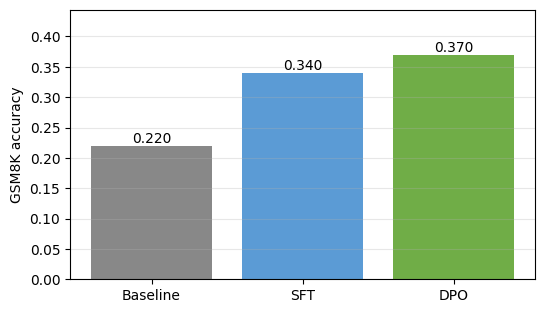

In [32]:
rows = []
for tag, f in [('Baseline','baseline.json'),('SFT','sft.json'),('DPO','dpo.json')]:
    p = RESULTS_DIR / f
    rows.append((tag, json.loads(p.read_text()) if p.exists() else None))

print(f"{'Stage':<10} {'Acc':>8} {'Δ acc':>9} {'Tok/s':>10} {'Mem(MB)':>10} {'N':>6}")
print('-'*60)
base_acc = rows[0][1]['accuracy'] if rows[0][1] else None
for tag, d in rows:
    if d is None:
        print(f'{tag:<10} {"—":>8} {"—":>9} {"—":>10} {"—":>10} {"—":>6}')
    else:
        mem = d.get('peak_memory_mb')
        mem_s = f'{mem:.0f}' if mem else '—'
        delta = f"{d['accuracy'] - base_acc:+.4f}" if base_acc is not None else '—'
        print(f"{tag:<10} {d['accuracy']:>8.4f} {delta:>9} {d['tokens_per_sec']:>10.1f} {mem_s:>10} {d['n']:>6}")

# Bar plot of accuracies
labels = [t for t,d in rows if d]
accs   = [d['accuracy'] for _,d in rows if d]
if accs:
    fig, ax = plt.subplots(figsize=(6,3.5))
    bars = ax.bar(labels, accs, color=['#888','#5b9bd5','#70ad47'])
    for b, a in zip(bars, accs):
        ax.text(b.get_x()+b.get_width()/2, a+0.005, f'{a:.3f}', ha='center', fontsize=10)
    ax.set_ylabel('GSM8K accuracy'); ax.set_ylim(0, max(accs)*1.2)
    ax.grid(True, axis='y', alpha=0.3); plt.show()

In [33]:
# Show 2 samples per stage
for tag, d in rows:
    if d is None: continue
    print(f'\n=== {tag} ===')
    for s in d.get('samples', [])[:2]:
        mark = 'OK' if s['ok'] else 'KO'
        print(f"[{mark}] gold={s['gold']} pred={s['pred']}")
        print('Q :', s['question'][:120])
        print('A :', s['output'][:280].replace('\n',' / '))
        print()


=== Baseline ===
[KO] gold=18 pred=3
Q : Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every da
A : <think> / Okay, let's see. Janet's ducks lay 16 eggs per day. She eats three for breakfast and bakes muffins for her friends every day with four. Then she sells the remainder at the farmers' market for $2 per egg. The question is asking how much she makes every day at the farmers' 

[OK] gold=3 pred=3
Q : A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?
A : <think> / Okay, let's see. The problem says a robe takes 2 bolts of blue fiber and half that much white fiber. I need to figure out how many bolts in total it takes. Hmm, let me break this down step by step. /  / First, the robe uses 2 bolts of blue fiber. That's straightforward. Now, 


=== SFT ===
[KO] gold=18 pred=128
Q : Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes m

## 7. Free-form prompt — switch adapter

In [34]:
# Set CHOICE to 'base' / 'sft' / 'dpo'
CHOICE = 'dpo'
MY_QUESTION = 'A bag has 1287 red marbles and 801 blue. If I draw 5 marbles without replacement, what is the expected number of red ones?'
SAMPLE = False     # True for stochastic with temperature
TEMP   = 0.7
MAX_TOKENS = 512

free_mem(globals().get('m_test'))
if CHOICE == 'base':
    m_test = load_model(None)
elif CHOICE == 'sft':
    m_test = model_sft if 'model_sft' in dir() and model_sft is not None else load_model(SFT_CKPT)
elif CHOICE == 'dpo':
    m_test = model_dpo if 'model_dpo' in dir() and model_dpo is not None else load_model(DPO_CKPT)
else:
    raise ValueError(CHOICE)

out = gen(m_test, MY_QUESTION, max_new_tokens=MAX_TOKENS, do_sample=SAMPLE, temperature=TEMP)
print('=== prompt ===')
print(MY_QUESTION)
print('\n=== output ===')
print(out)
print('\npredicted #:', parse_predicted_answer(out))

=== prompt ===
A bag has 1287 red marbles and 801 blue. If I draw 5 marbles without replacement, what is the expected number of red ones?

=== output ===
<think>
The total number of marbles in the bag is 1287 + 801 = <<1287+801=2088>>2088 marbles.
The expected number of red marbles drawn is 1287/2088 * 5 = <<1287/2088*5=3>>3 marbles.
</think>

The answer is: #### 3

predicted #: 3
